In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,root_mean_squared_error

In [5]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/Employers_data.csv')
data

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Thomas Rossin,51,Male,Sales,Executive,28,Master,Austin,185000
9996,9997,Christie King,36,Female,Sales,Executive,9,PhD,San Francisco,165000
9997,9998,Alfred Keller,57,Male,Sales,Executive,30,PhD,New York,200000
9998,9999,Margaret Gomez,37,Female,Engineering,Manager,14,Master,New York,135000


In [7]:
data.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Gender,0
Department,0
Job_Title,0
Experience_Years,0
Education_Level,0
Location,0
Salary,0


In [9]:
data.describe()

,Employee_ID,Age,Experience_Years,Salary
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.455900,12.370900,115381.500000
std,2886.89568,10.000213,9.148951,46066.139047
min,1.00000,21.000000,0.000000,25000.000000
25%,2500.75000,27.000000,5.000000,70000.000000
50%,5000.50000,34.000000,10.000000,120000.000000
75%,7500.25000,43.000000,19.000000,150000.000000
max,10000.00000,60.000000,37.000000,215000.000000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


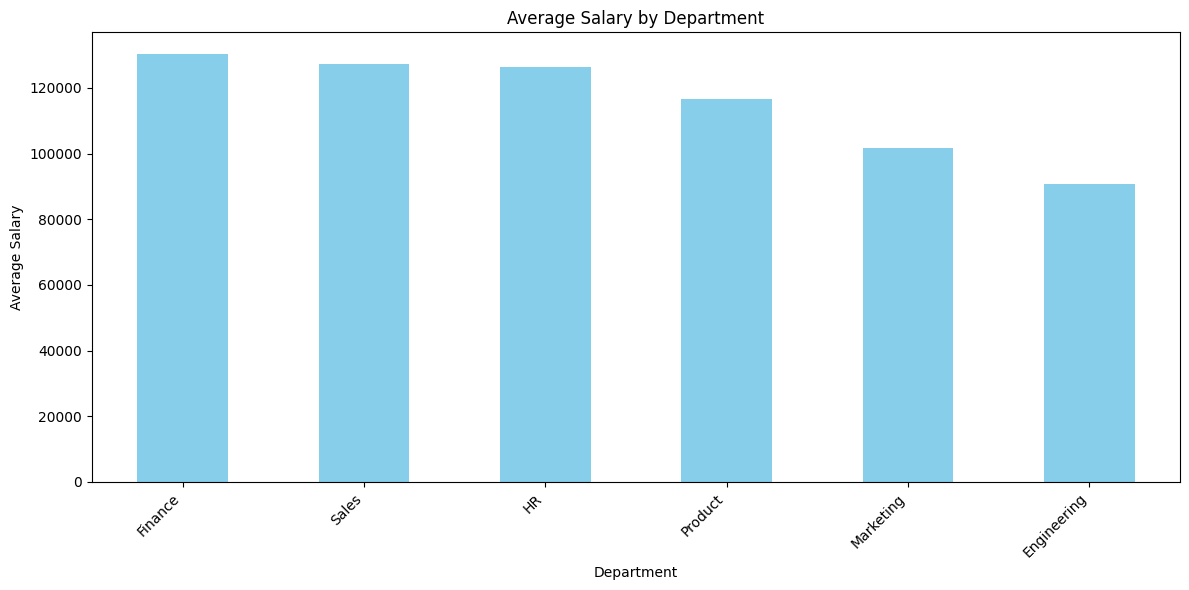

In [14]:
avg_salary_by_department = data.groupby('Department')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_salary_by_department.plot(kind='bar', color='skyblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
object_cols = data.select_dtypes(include='object').columns.tolist()
if 'Name' in object_cols:
    object_cols.remove('Name')
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("DataFrame after converting categorical object columns to int using Label Encoding:")
data.info()
print("\nFirst 5 rows of the modified DataFrame:")
print(data.head())

DataFrame after converting categorical object columns to int using Label Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  int64 
 4   Department        10000 non-null  int64 
 5   Job_Title         10000 non-null  int64 
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  int64 
 8   Location          10000 non-null  int64 
 9   Salary            10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB

First 5 rows of the modified DataFrame:
   Employee_ID            Name  Age  ...  Education_Level  Location  Salary
0            1    Merle Ingram   24  ...                1         0   90000
1           

In [18]:
X = data.drop(['Name', 'Salary'], axis=1)
y = data['Salary']
print("\nFeatures (X) shape:", X.shape)
print("\nTarget (y) shape:", y.shape)


Features (X) shape: (10000, 8)

Target (y) shape: (10000,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [27]:

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = rf_regressor.predict(X_test_scaled)


In [30]:
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.989746572830898
Mean Absolute Error: 3720.925
Mean Squared Error: 21610758.75
Root Mean Squared Error: 4648.737328565683


In [41]:
import pickle


In [42]:
with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(rf_regressor, model_file)

In [43]:
with open('random_forest_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

In [46]:
new_employee_data = np.array([
    10001,  # Employee_ID
    30,     # Age
    0,      # Gender (e.g., Male - encoded)
    0,      # Department (e.g., Finance - encoded)
    0,      # Job_Title (e.g., Analyst - encoded)
    5,      # Experience_Years
    0,      # Education_Level (e.g., Bachelor - encoded)
    0       # Location (e.g., Austin - encoded)
]).reshape(1,-1)
new_employee_data_scaled = scaler.transform(new_employee_data)
loaded_model = rf_regressor.predict(new_employee_data_scaled)
print(f"Predicted Salary for the new employee:{loaded_model[0]}")

Predicted Salary for the new employee:78800.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
